# 03c: Demand Forecasting with a Feed-Forward Neural Network

This notebook trains a feed-forward neural network (FFNN) to forecast taxi pickup demand per H3 hexagon and time bucket, using the same panel and feature set as the SVM notebook for a direct comparison.

The workflow covers the following steps:

1. **Data and feature preparation:** Load the panel via `prepare_modelling()`, apply log1p transformation to the target, one-hot encode hexagon ids, and split 50/20/30 into train/validation/test (mirroring the SVM notebook for comparability).
2. **Model architecture:** A Keras Sequential network with configurable depth, width, BatchNormalization, Dropout, and a linear output neuron for regression.
3. **Hyperparameter grid search:** Hidden layer sizes, dropout rate, learning rate, and optimizer are swept; the best configuration is selected by validation MAE.
4. **Activation function comparison:** ReLU, tanh, and sigmoid are compared on training loss curves using the best hyperparameters.
5. **Final evaluation:** The best model is scored on the held-out test set against a climatology baseline (per cell x time slot x weekend average).
6. **Custom demand prediction:** A manual inference cell lets you query the model for any hexagon, time, and weather context.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product

import keras
from keras import models, layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make scripts/ importable
path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
os.chdir(Path(path))

from scripts.helpers.modelling import prepare_modelling

SEED = 0
# 0, 123
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

# ── Spatio-temporal resolution ────────────────────────────────────────────────
RESOLUTION = 6   # H3 resolution (5 ~coarse 6 = ~medium 7 = ~fine)
FREQ_HOURS = 4   # 1h/4h/8h time bucket width in hours (must match freq below)
# ──────────────────────────────────────────────────────────────────────────────

For now, we load the feature dataframe for the spatial H3 resolution 6 and the temporal resolution of 4-hour buckets to perform the hyperparameter tuning (we already know the dataset contains meaningful demand patters at this spatial and temporal resolution, see `02_spatial_analytics.ipynb`). Later on in the notebook, we compare different spatial and temporal resolutions.

In [2]:
df = prepare_modelling(resolution=RESOLUTION, freq=f'{FREQ_HOURS}h')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 137889 entries, 0 to 137888
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   h3_id                 137889 non-null  string        
 1   time_bucket           137889 non-null  datetime64[us]
 2   trip_count            137889 non-null  int64         
 3   is_weekend            137889 non-null  bool          
 4   is_holiday            137889 non-null  bool          
 5   hour_sin              137889 non-null  Float64       
 6   hour_cos              137889 non-null  Float64       
 7   day_of_week_sin       137889 non-null  Float64       
 8   day_of_week_cos       137889 non-null  Float64       
 9   month_sin             137889 non-null  Float64       
 10  month_cos             137889 non-null  Float64       
 11  temperature_2m        137889 non-null  float64       
 12  apparent_temperature  137889 non-null  float64       
 13  precipitat

The panel spans 137,889 hexagon × time-bucket rows across 27 hexagons at H3 resolution 6 with 4-hour buckets, built with the same `prepare_modelling` panel and feature set as the SVM notebook for a direct comparison.

## Data & feature preparation

The target is `log1p(trip_count)`. Demand is a heavily zero-inflated, right-skewed count, so working on the log scale keeps the loss well behaved.

For spatial information we one-hot encode the hexagon id, which gives every cell its own binary column.

The split is a random 50 / 20 / 30, with rows shuffled beforehand.

For more detail on these choices, see the SVM notebook, since the two are set up to be directly comparable.

In [3]:
# Prediction-Target: log1p-transformed trip count (invert with np.expm1 for interpretable metrics)
y = np.log1p(df['trip_count'])

drop_cols = ['h3_id', 'time_bucket', 'trip_count']

# Spatial encoding: one-hot hexagon id — gives binary column for each cell
hex_ohe = pd.get_dummies(df['h3_id'], prefix='hex', dtype=float)

# Add the one-hot hexagon encoding binary features as a column to the dataframe
x = pd.concat(
    [df.drop(columns=drop_cols), hex_ohe],
    axis=1,
).astype(float)

print(f"Feature matrix: {x.shape[0]:,} rows × {x.shape[1]} features")

Feature matrix: 137,889 rows × 51 features


In [4]:
#x.info

In [5]:
# Random 50 / 20 / 30 split — mirrors the SVM notebook for a fair comparison
train_idx, temp_idx = train_test_split(df.index, train_size=0.50, random_state=SEED, shuffle=True)
val_idx,   test_idx = train_test_split(temp_idx, train_size=0.40, random_state=SEED, shuffle=True)

x_train, y_train = x.loc[train_idx], y.loc[train_idx]
x_val,   y_val   = x.loc[val_idx],   y.loc[val_idx]
x_test,  y_test  = x.loc[test_idx],  y.loc[test_idx]

print(f"train {len(x_train):>7,}  ({len(x_train)/len(df):.0%})")
print(f"val   {len(x_val):>7,}  ({len(x_val)/len(df):.0%})")
print(f"test  {len(x_test):>7,}  ({len(x_test)/len(df):.0%})")

train  68,944  (50%)
val    27,578  (20%)
test   41,367  (30%)


The split lands almost exactly on the intended 50 / 20 / 30 proportions (68,944 / 27,578 / 41,367 rows).

StandardScaler normalises all features to zero mean and unit variance,
ensuring no single feature dominates the gradient updates due to its scale.

In [6]:
# Fit scaler on train only, then transform all splits
scaler = StandardScaler()

X_train_s = scaler.fit_transform(x_train)
X_val_s   = scaler.transform(x_val)
X_test_s  = scaler.transform(x_test)

INPUT_DIM = X_train_s.shape[1]
print(f"Input dim: {INPUT_DIM}")

Input dim: 51


## Model architecture

A fully-connected Keras Sequential model with:
- configurable depth, width, and activation
- BatchNormalization after each hidden layer
- Dropout for regularisation
- a single linear output neuron (predicting log1p demand)

In [7]:
def build_model(hidden_dims, dropout=0.2, activation='relu', lr=1e-3, optimizer='adam', input_dim=None):
    """Build and compile a Keras Sequential FFNN for demand regression."""
    dim = input_dim if input_dim is not None else INPUT_DIM
    opt = keras.optimizers.Adam(lr) if optimizer == 'adam' else keras.optimizers.SGD(lr)

    model = models.Sequential()
    model.add(layers.Input(shape=(dim,))) 
    for h in hidden_dims:
        model.add(layers.Dense(h))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))  # linear output for regression

    model.compile(optimizer=opt, loss='mse')
    return model
    # mse, poisson wegen counts, squared error, absolute error

# Quick sanity check
# build_model([32, 16]).summary()


## Hyperparameter grid search

| Parameter | Values tried |
|---|---|
| hidden layer sizes | `[64,64]`, `[256,256]`, `[128,64]`, `[64,64,64,64]` |
| dropout | `0.0`, `0.1`, `0.2` |
| learning rate | `0.1`, `0.01`, `0.001` |
| optimizer | `sgd`, `adam` |

Models are trained on `train` and scored on `val`. The best combination is then
retrained on `train+val` (Section 5).

> **Runtime note:** the grid runs 4×2×3×2 = 54 fits. Reduce `epochs` or narrow the grid
> if iteration speed matters.

In [8]:
# ── Hyperparameter grid ────────────────────────────────────────────────────────
HIDDEN_CONFIGS = [[64, 64], [128, 64], [256, 256], [64, 64, 64, 64]]
DROPOUTS       = [0.0, 0.1]
LRS            = [0.1, 0.01, 0.001]
OPTIMIZERS     = ['sgd', 'adam']
# ──────────────────────────────────────────────────────────────────────────────
best_val_mae, best_config = np.inf, None
grid_results = []


for hidden, drop, lr, opt in product(HIDDEN_CONFIGS, DROPOUTS, LRS, OPTIMIZERS):
    keras.utils.set_random_seed(SEED)
    m = build_model(hidden, dropout=drop, lr=lr, optimizer=opt)

    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


    m.fit(
        X_train_s, y_train.values,
        validation_data=(X_val_s, y_val.values),
        epochs=50, batch_size=512,
        callbacks=[es], verbose=0,
    )
    pred = np.expm1(m.predict(X_val_s, batch_size=2048, verbose=0).squeeze())
    pred = np.nan_to_num(pred, nan=1e9, posinf=1e9, neginf=1e9)
    val_mae = mean_absolute_error(np.expm1(y_val.values), pred)
    grid_results.append({'hidden': hidden, 'dropout': drop, 'lr': lr,
                         'optimizer': opt, 'val_MAE': round(val_mae, 3)})
    print(f"hidden={hidden}  drop={drop}  lr={lr}  opt={opt}  →  val MAE={val_mae:.3f}")
    if val_mae < best_val_mae:
        best_val_mae, best_config = val_mae, {'hidden': hidden, 'dropout': drop, 'lr': lr, 'optimizer': opt}

grid_df = pd.DataFrame(grid_results).sort_values('val_MAE')
print(f"\nBest config: {best_config}  →  val MAE={best_val_mae:.3f}")
grid_df

hidden=[64, 64]  drop=0.0  lr=0.1  opt=sgd  →  val MAE=24.852
hidden=[64, 64]  drop=0.0  lr=0.1  opt=adam  →  val MAE=26.012
hidden=[64, 64]  drop=0.0  lr=0.01  opt=sgd  →  val MAE=24.388
hidden=[64, 64]  drop=0.0  lr=0.01  opt=adam  →  val MAE=24.153
hidden=[64, 64]  drop=0.0  lr=0.001  opt=sgd  →  val MAE=35.388
hidden=[64, 64]  drop=0.0  lr=0.001  opt=adam  →  val MAE=23.629
hidden=[64, 64]  drop=0.1  lr=0.1  opt=sgd  →  val MAE=25.199
hidden=[64, 64]  drop=0.1  lr=0.1  opt=adam  →  val MAE=27.805
hidden=[64, 64]  drop=0.1  lr=0.01  opt=sgd  →  val MAE=26.420
hidden=[64, 64]  drop=0.1  lr=0.01  opt=adam  →  val MAE=24.062
hidden=[64, 64]  drop=0.1  lr=0.001  opt=sgd  →  val MAE=40.932
hidden=[64, 64]  drop=0.1  lr=0.001  opt=adam  →  val MAE=24.649
hidden=[128, 64]  drop=0.0  lr=0.1  opt=sgd  →  val MAE=22.295
hidden=[128, 64]  drop=0.0  lr=0.1  opt=adam  →  val MAE=24.066
hidden=[128, 64]  drop=0.0  lr=0.01  opt=sgd  →  val MAE=23.025
hidden=[128, 64]  drop=0.0  lr=0.01  opt=adam  

,hidden,dropout,lr,optimizer,val_MAE
29,"[256, 256]",0.0,0.001,adam,2.004000e+01
21,"[128, 64]",0.1,0.010,adam,2.092800e+01
41,"[64, 64, 64, 64]",0.0,0.001,adam,2.106000e+01
35,"[256, 256]",0.1,0.001,adam,2.132000e+01
27,"[256, 256]",0.0,0.010,adam,2.133600e+01
15,"[128, 64]",0.0,0.010,adam,2.136900e+01
25,"[256, 256]",0.0,0.100,adam,2.144900e+01
36,"[64, 64, 64, 64]",0.0,0.100,sgd,2.205100e+01
26,"[256, 256]",0.0,0.010,sgd,2.210500e+01
12,"[128, 64]",0.0,0.100,sgd,2.229500e+01


Adam with a low learning rate (0.001) on the widest two-layer architecture, `[256, 256]`, comes out on top with a validation MAE of about 20.0. Worth noting: SGD completely falls apart at a high learning rate on that same architecture (val MAE explodes to roughly 1e9), which shows that wider networks need a much more carefully tuned learning rate when trained with plain SGD instead of Adam.

## Activation function comparison

Using the best hyperparameters from the grid, we train one model per activation function
and compare their training loss curves. Architecture and optimizer are held fixed.

    RELU  →  val MAE=21.928
    TANH  →  val MAE=20.043
 SIGMOID  →  val MAE=93.286


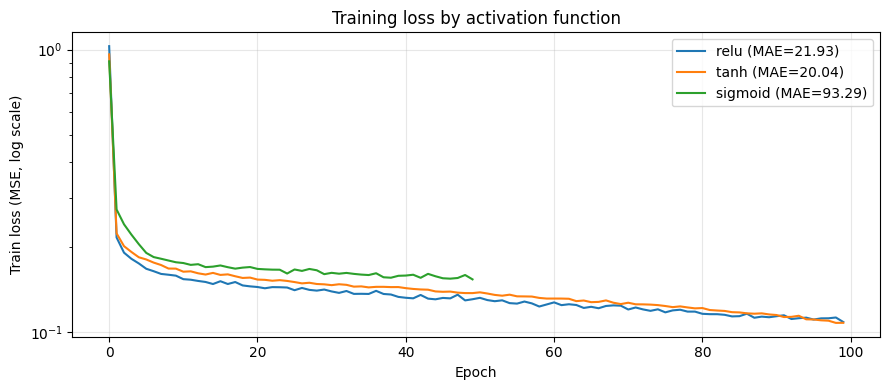

In [9]:
BEST_HIDDEN  = best_config['hidden']
BEST_DROPOUT = best_config['dropout']
BEST_LR      = best_config['lr']
BEST_OPT     = best_config['optimizer']

ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
act_results = {}
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

for act_name in ACTIVATIONS:
    m = build_model(BEST_HIDDEN, dropout=BEST_DROPOUT, activation=act_name,
                    lr=BEST_LR, optimizer=BEST_OPT)
    hist = m.fit(
        X_train_s, y_train.values,
        validation_data=(X_val_s, y_val.values),
        epochs=100, batch_size=512,
        callbacks=[es], verbose=0,
    )
    pred = np.expm1(m.predict(X_val_s, verbose=0).squeeze())
    pred = np.nan_to_num(pred, nan=1e9, posinf=1e9, neginf=1e9)
    val_mae = mean_absolute_error(np.expm1(y_val.values), pred)
    act_results[act_name] = {'losses': hist.history['loss'], 'val_MAE': val_mae}
    print(f"{act_name.upper():>8}  →  val MAE={val_mae:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
for act_name, res in act_results.items():
    ax.plot(res['losses'], label=f"{act_name} (MAE={res['val_MAE']:.2f})")
ax.set_xlabel('Epoch')
ax.set_ylabel('Train loss (MSE, log scale)')
ax.set_yscale('log')
ax.set_title('Training loss by activation function')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ReLU and tanh perform comparably (val MAE 21.9 vs. 20.0), with ReLU converging faster and staying lower for most of training and tanh only edging ahead right at the end; both leave sigmoid far behind (93.3), which saturates and slows learning in a network of this depth. ReLU is retained for the final model as the faster and more stable of the two.

## Final model

Retrain the best configuration from the grid search (widest hidden layers, low learning rate, Adam) on the same train/validation split, this time with early stopping so the model doesn't overfit before the untouched test set is scored.

In [10]:
print(f"Best config: hidden={BEST_HIDDEN}, dropout={BEST_DROPOUT}, lr={BEST_LR}, optimizer={BEST_OPT}")

es_final = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

# Train on train, monitor val for early stopping — test is never touched here
model_final = build_model(BEST_HIDDEN, dropout=BEST_DROPOUT,
                          lr=BEST_LR, optimizer=BEST_OPT)
history_final = model_final.fit(
    X_train_s, y_train.values,
    validation_data=(X_val_s, y_val.values),
    epochs=200, batch_size=512,
    callbacks=[es_final],
    verbose=1,
)

# Old: test_loss = model_final.evaluate(X_test_s, y_test.values, verbose=0)

# Compute pred_final once — reused for test_loss in the plot and metrics in evaluation
pred_final = np.expm1(model_final.predict(X_test_s, verbose=0).squeeze())
test_loss  = mean_squared_error(y_test.values, np.log1p(pred_final))

Best config: hidden=[256, 256], dropout=0.0, lr=0.001, optimizer=adam
Epoch 1/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6278 - val_loss: 1.2232
Epoch 2/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2097 - val_loss: 0.3574
Epoch 3/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1885 - val_loss: 0.2588
Epoch 4/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1749 - val_loss: 0.1827
Epoch 5/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1719 - val_loss: 0.1757
Epoch 6/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1658 - val_loss: 0.1848
Epoch 7/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1640 - val_loss: 0.1837
Epoch 8/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1609 - val_loss: 0.1731
Epoch 9/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1575 - val_loss: 0.1650
Epoch 10/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1571 - val_loss: 0.1693
Epoch 11/200
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - los

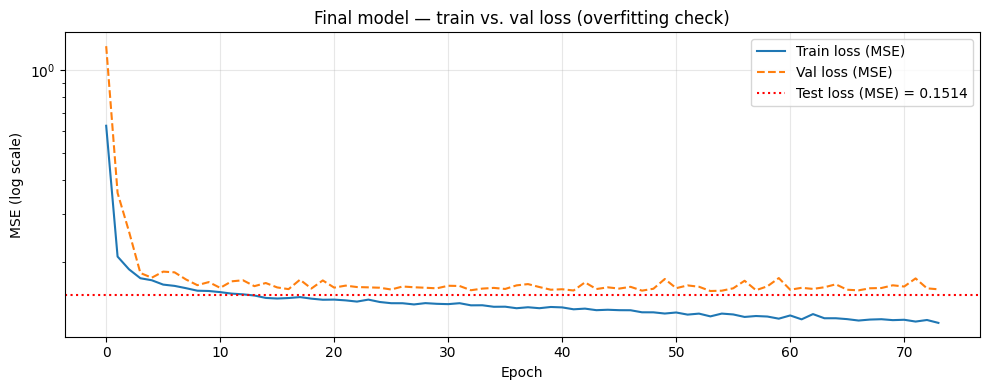

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_final.history['loss'],     label='Train loss (MSE)')
ax.plot(history_final.history['val_loss'], label='Val loss (MSE)', linestyle='--')
ax.axhline(y=test_loss, color='red', linestyle=':', label=f'Test loss (MSE) = {test_loss:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log scale)')
ax.set_yscale('log')
ax.set_title('Final model — train vs. val loss (overfitting check)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Train and validation loss track closely with no widening gap, and early stopping restores the best weights once validation loss stops improving. There's no strong sign of overfitting on this split.

## Sophisticated Evaluation

Score the final model on the held-out test set in the original count scale (not log space), and compare it against a climatology baseline (the mean trip count per cell x time-slot x weekend - see explanation in `03b_svm.ipynb`) to see whether it actually beats a simple historical average.

In [12]:
y_test_orig = df.loc[test_idx, 'trip_count'].values

def _report(name, pred_raw, y_true_raw):
    """Return a metrics dict comparing raw (count-space) predictions to truth."""
    return dict(
        model = name,
        MAE   = mean_absolute_error(y_true_raw, pred_raw),
        RMSE  = np.sqrt(mean_squared_error(y_true_raw, pred_raw)),
        MedAE = np.median(np.abs(pred_raw - y_true_raw)),
        R2    = r2_score(y_true_raw, pred_raw),
        bias  = np.mean(pred_raw - y_true_raw),
    )

# Climatology: build lookup from train only, apply to test
clim_df = df.loc[train_idx].copy()
clim_df['slot'] = clim_df['time_bucket'].dt.hour // FREQ_HOURS
clim_key = clim_df.groupby(['h3_id', 'slot', 'is_weekend'])['trip_count'].mean()

test_df = df.loc[test_idx].copy()
test_df['slot'] = test_df['time_bucket'].dt.hour // FREQ_HOURS
pred_clim = test_df.join(clim_key.rename('clim'), on=['h3_id', 'slot', 'is_weekend'])['clim'].fillna(0).values

pd.DataFrame([
    _report('climatology (cell × slot × weekend)', pred_clim,  y_test_orig),
    _report(f'FFNN tuned {BEST_HIDDEN}',           pred_final, y_test_orig),
]).set_index('model').round(3)

,MAE,RMSE,MedAE,R2,bias
model,,,,,
climatology (cell × slot × weekend),24.420,87.222,2.866,0.937,-1.078
"FFNN tuned [256, 256]",21.156,80.776,2.733,0.946,-8.253


The tuned FFNN beats the climatology baseline on MAE, RMSE, and R² (21.2 vs. 24.4 MAE; R² 0.946 vs. 0.937), but it under-predicts substantially more on average (bias -8.3 vs. -1.1).

## Custom Demand Prediction

Predict expected trip demand for any spatio-temporal context, directly addressing 
the core business question: **"What demand can we expect on a rainy Sunday at 10am
around the outskirts of the city?"**

Fill in the variables below and run the cell. The hexagon IDs are printed first, copy the full `hex_...` string into `HEX_ID`.

In [13]:
# Available hexagon IDs:
print(df['h3_id'].unique())

# Available hexagon IDs — copy the full hex_... string into HEX_ID below
# print(sorted(['hex_' + h for h in df['h3_id'].unique()]))

<StringArray>
['862664197ffffff', '8626641b7ffffff', '862664527ffffff', '86266452fffffff',
 '862664567ffffff', '86266456fffffff', '862664577ffffff', '862664c17ffffff',
 '862664c1fffffff', '862664c87ffffff', '862664c8fffffff', '862664ca7ffffff',
 '862664cafffffff', '862664cb7ffffff', '862664cc7ffffff', '862664ccfffffff',
 '862664cd7ffffff', '862664cdfffffff', '862664ce7ffffff', '862664cefffffff',
 '862664cf7ffffff', '862664d87ffffff', '862664d8fffffff', '862664d9fffffff',
 '862759347ffffff', '86275934fffffff', '86275936fffffff']
Length: 27, dtype: string


In [14]:
# ── User-defined context ──────────────────────────────────────────────────────
HEX_ID      = 'hex_862664cc7ffffff'  # H3 hexagon id (copy from above)
HOUR_FROM   = 10                     # start hour (inclusive)
HOUR_TO     = 18                     # end hour (inclusive)
DAY_OF_WEEK = 6                      # 0=Monday … 6=Sunday
MONTH       = 7                      # 1=January … 12=December
IS_WEEKEND  = 1                      # 1=weekend, 0=weekday
IS_HOLIDAY  = 0                      # 1=public holiday, 0=normal day

# Weather
TEMPERATURE       = 28.0   # °C
APPARENT_TEMP     = 26.0   # °C (feels-like)
PRECIPITATION     = 5.0    # mm
RAIN              = 5.0    # mm
SNOWFALL          = 0.0    # cm
SNOW_DEPTH        = 0.0    # cm
WINDSPEED         = 15.0   # km/h
WINDGUSTS         = 25.0   # km/h
CLOUD_COVER       = 80.0   # %

# POI counts for the hexagon (copy from df for the chosen hex)
N_POI_ACCOMMODATION  = 2
N_POI_EDUCATION      = 1
N_POI_ENTERTAINMENT  = 5
N_POI_FOOD_NIGHTLIFE = 12
N_POI_HEALTHCARE     = 3
N_POI_SHOPPING       = 8
N_POI_TRANSPORT      = 4
# ──────────────────────────────────────────────────────────────────────────────

MONTH_NAMES = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June',
               7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}

pred_rows = []
for hour in range(HOUR_FROM, HOUR_TO + 1):
    query = pd.DataFrame([{col: 0.0 for col in x.columns}])

    query['hour_sin']        = np.sin(2 * np.pi * hour / 24)
    query['hour_cos']        = np.cos(2 * np.pi * hour / 24)
    query['day_of_week_sin'] = np.sin(2 * np.pi * DAY_OF_WEEK / 7)
    query['day_of_week_cos'] = np.cos(2 * np.pi * DAY_OF_WEEK / 7)
    query['month_sin']       = np.sin(2 * np.pi * (MONTH - 1) / 12)
    query['month_cos']       = np.cos(2 * np.pi * (MONTH - 1) / 12)
    query['is_weekend']      = float(IS_WEEKEND)
    query['is_holiday']      = float(IS_HOLIDAY)

    query['temperature_2m']       = TEMPERATURE
    query['apparent_temperature']  = APPARENT_TEMP
    query['precipitation']         = PRECIPITATION
    query['rain']                  = RAIN
    query['snowfall']              = SNOWFALL
    query['snow_depth']            = SNOW_DEPTH
    query['windspeed_10m']         = WINDSPEED
    query['windgusts_10m']         = WINDGUSTS
    query['cloud_cover']           = CLOUD_COVER

    query['n_poi_accommodation']  = N_POI_ACCOMMODATION
    query['n_poi_education']      = N_POI_EDUCATION
    query['n_poi_entertainment']  = N_POI_ENTERTAINMENT
    query['n_poi_food_nightlife'] = N_POI_FOOD_NIGHTLIFE
    query['n_poi_healthcare']     = N_POI_HEALTHCARE
    query['n_poi_shopping']       = N_POI_SHOPPING
    query['n_poi_transport']      = N_POI_TRANSPORT

    if HEX_ID in query.columns:
        query[HEX_ID] = 1.0
    else:
        print(f"Warning: '{HEX_ID}' not found in feature columns.")
        break

    pred = max(0.0, np.expm1(model_final.predict(scaler.transform(query), verbose=0).squeeze()))
    pred_rows.append({'hour': f'{hour:02d}:00', 'predicted_trips': round(float(pred), 1)})

result_df = pd.DataFrame(pred_rows).set_index('hour')
print(f"Hexagon: {HEX_ID} | {'Weekend' if IS_WEEKEND else 'Weekday'} | Month: {MONTH_NAMES[MONTH]}")
result_df.loc['Total'] = result_df['predicted_trips'].sum().round(1)
result_df

Hexagon: hex_862664cc7ffffff | Weekend | Month: July


,predicted_trips
hour,
10:00,34.4
11:00,36.3
12:00,37.3
13:00,36.1
14:00,34.1
15:00,31.5
16:00,27.5
17:00,24.1
18:00,20.4


For this rainy Sunday scenario, predicted demand peaks around midday (12:00-13:00) and tapers off through the afternoon toward the edges of the window, consistent with typical midday leisure travel.

## Temporal Comparison Code of SVM (adjust)

Repeat the SVM notebook's spatial/temporal resolution sweep for the FFNN, using a fast subsampled training routine (`quick_score_nn`) so the full 3×3 grid of H3 resolutions and time-bucket widths stays tractable.

Scoring resolution=5, freq=1h ...
Scoring resolution=5, freq=4h ...
Scoring resolution=5, freq=8h ...
Scoring resolution=6, freq=1h ...
Scoring resolution=6, freq=4h ...
Scoring resolution=6, freq=8h ...
Scoring resolution=7, freq=1h ...
Scoring resolution=7, freq=4h ...
Scoring resolution=7, freq=8h ...


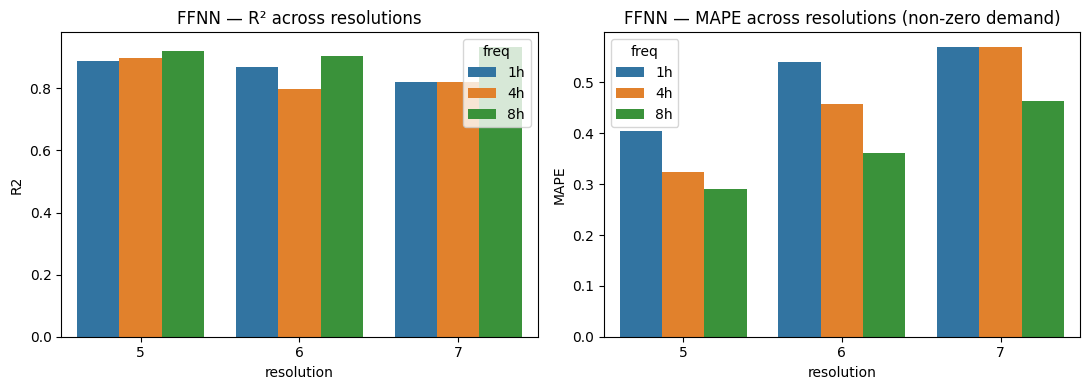

,resolution,freq,n_rows,n_hex,MAE,R2,MAPE
0,5,1h,163400,8,22.743,0.889,0.405
1,5,4h,40856,8,79.403,0.897,0.323
2,5,8h,20432,8,175.594,0.920,0.290
3,6,1h,551475,27,9.421,0.868,0.540
4,6,4h,137889,27,36.548,0.799,0.458
5,6,8h,68958,27,53.811,0.905,0.361
6,7,1h,2614400,128,2.735,0.821,0.570
7,7,4h,653696,128,9.276,0.822,0.570
8,7,8h,326912,128,10.623,0.934,0.464


In [15]:
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns

def quick_score_nn(panel, n=6_000, seed=1):
    """Train FFNN with best_config on a subsample of panel; return MAE, R2, MAPE."""
    yy = np.log1p(panel['trip_count'])
    hex_d = pd.get_dummies(panel['h3_id'], prefix='hex', dtype=float)
    xx = pd.concat([panel.drop(columns=['trip_count', 'h3_id', 'time_bucket']), hex_d], axis=1).astype(float)

    valid = xx.notna().all(axis=1)
    xx, yy = xx.loc[valid], yy.loc[valid]

    tr_idx, te_idx = train_test_split(xx.index, train_size=0.7, random_state=SEED, shuffle=True)
    
    # Subsample for speed
    rng = np.random.RandomState(seed)
    tr_sub = rng.choice(tr_idx, size=min(n, len(tr_idx)), replace=False)
    te_sub = rng.choice(te_idx, size=min(n // 2, len(te_idx)), replace=False)

    sc = StandardScaler()
    X_tr = sc.fit_transform(xx.loc[tr_sub])
    X_te = sc.transform(xx.loc[te_sub])

    keras.utils.set_random_seed(SEED)
    m = build_model(
        best_config['hidden'], dropout=best_config['dropout'],
        lr=best_config['lr'], optimizer=best_config['optimizer'],
        input_dim=X_tr.shape[1],
    )
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
    m.fit(X_tr, yy.loc[tr_sub].values,
          validation_data=(X_te, yy.loc[te_sub].values),
          epochs=100, batch_size=512, callbacks=[es], verbose=0)

    pred = np.expm1(m.predict(X_te, verbose=0).squeeze())
    pred = np.clip(np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0), 0, None)
    true = np.expm1(yy.loc[te_sub].values)
    nonzero = true > 0

    return {
        'n_rows': len(panel), 'n_hex': panel['h3_id'].nunique(),
        'MAE':  mean_absolute_error(true, pred),
        'R2':   r2_score(true, pred),
        'MAPE': mean_absolute_percentage_error(true[nonzero], pred[nonzero]),
    }

SENSITIVITY_CONFIGS = [(r, f) for r in [5, 6, 7] for f in ['1h', '4h', '8h']]

sens_rows = []
for resolution, freq in SENSITIVITY_CONFIGS:
    print(f"Scoring resolution={resolution}, freq={freq} ...")
    panel = df if (resolution == RESOLUTION and freq == f'{FREQ_HOURS}h') \
            else prepare_modelling(resolution=resolution, freq=freq)
    sens_rows.append({'resolution': resolution, 'freq': freq, **quick_score_nn(panel)})

sensitivity = pd.DataFrame(sens_rows).round(3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=sensitivity, x='resolution', y='R2', hue='freq', ax=axes[0])
axes[0].set_title('FFNN — R² across resolutions')
sns.barplot(data=sensitivity, x='resolution', y='MAPE', hue='freq', ax=axes[1])
axes[1].set_title('FFNN — MAPE across resolutions (non-zero demand)')
plt.tight_layout()
plt.show()

sensitivity

Across the full grid, absolute error (MAE) drops sharply as the hexagons get smaller, simply because each cell has fewer trips to predict. Widening the time bucket pulls in the opposite direction: aggregating more trips into each 4h or 8h slot pushes MAE back up, since the target itself gets larger.

MAPE is scale free and only measured on cells with nonzero demand, so it gives a cleaner read on relative accuracy. It tends to be a bit higher at finer resolutions, since more and smaller cells make for noisier relative predictions, and it generally eases as the time bucket widens.

R² stays fairly high across all resolutions (roughly the 0.80 to 0.93 range) but is noisy on these subsampled fits, without a clean trend from coarse to fine. Taken together, resolution 6 looks like a reasonable middle ground for this dataset: fine enough to be spatially useful, without the extra relative noise (higher MAPE) that comes with going to resolution 7.